<a href="https://colab.research.google.com/github/ZahraRasooli-200/MATLAB-practice/blob/main/dog_cat_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset , random_split
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

In [26]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.RandomCrop((28,28)),
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

In [27]:
full_dataset = OxfordIIITPet(root='/data', split='trainval',transform=transform, download=True)

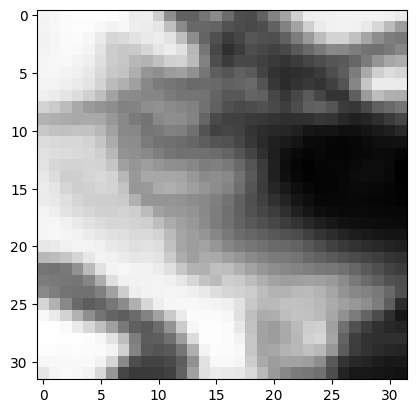

In [28]:
import matplotlib.pyplot as plt
plt.imshow(full_dataset[0][0].view(32,32), cmap='gray')


In [29]:
full_dataset[0]

(tensor([0.9922, 0.9843, 0.9922,  ..., 0.2353, 0.2157, 0.2039]), 0)

In [30]:
#full_dataset.classes
persian_class = full_dataset.classes.index('Persian')
shiba_inu_class = full_dataset.classes.index('Shiba Inu')
saint_bernard_class = full_dataset.classes.index('Saint Bernard')

selected_indices = []
for idx, data in enumerate(full_dataset):
    if data[1] == persian_class:
        selected_indices.append(idx)
        full_dataset._labels[idx] = 0

    if data[1] == shiba_inu_class:
        selected_indices.append(idx)
        full_dataset._labels[idx] = 1

    if data[1] == saint_bernard_class:
        selected_indices.append(idx)
        full_dataset._labels[idx] = 2

selected_dataset = Subset(full_dataset, selected_indices)
len(selected_dataset)

300

In [31]:
train_dataset ,val_dataset = random_split(selected_dataset, [0.8,0.2], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)

In [32]:
#class OneLayerNN(nn.Module):
  #def __init__(self):
    #super().__init__()
    #self.net = nn.Sequential(nn.Linear(32*32,1))
  #def forward(self,x):
    #return self.net(x).squeeze(1)


class FourLayerNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(nn.Linear(32*32,256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128,64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64,3)
    )
  def forward(self,x):
    return self.net(x)

In [33]:
model = FourLayerNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

In [34]:
epochs = 300
best_acc = 0
for epoch in range(epochs):
  model.train()
  train_loss = 0
  corrects = 0
  total = 0
  for images, targets in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    predictions = outputs.argmax(dim=1)
    corrects += (predictions == targets).sum().item()
    total += outputs.size(0)
  train_acc = corrects / total
  train_loss = train_loss / len(train_loader)
  lr_scheduler.step()

#eval
model.eval()
with torch.no_grad():
  val_loss = 0
  corrects = 0
  total = 0
  for images, targets in val_loader:
    outputs = model(images)
    val_loss += criterion(outputs, targets).item()
    predictions = outputs.argmax(dim=1)
    corrects += (predictions == targets).sum().item()
    total += outputs.size(0)
  val_loss = val_loss / len(val_loader)
  val_acc = corrects / total

if val_acc > best_acc:
  best_acc = val_acc
  torch.save(model.state_dict(), 'best_model.pth')
  print(f'best model save with acc: {best_acc:.2f}')
print(f'Epoch {epoch}, Train Loss: {train_loss:.2f}, Val Loss: {val_loss:.2f},train acc: {train_acc:.2f}, Val Acc: {val_acc:.2f}, train error: {1-train_acc:.2f}, val error: {1-val_acc:.2f}')

best model save with acc: 0.53
Epoch 299, Train Loss: 0.43, Val Loss: 1.10,train acc: 0.82, Val Acc: 0.53, train error: 0.18, val error: 0.47


In [41]:
def predict(input_image):
  model = FourLayerNN()
  model.load_state_dict(torch.load('best_model.pth'))
  outputs = model(input_image)
  predictions = outputs.Softmax(dim=1)
  print(predictions)
  plt.figure(figsize=(2,2))
  plt.imshow(input_image.view(32,32), cmap='gray')